<div style="text-align: center;">

  <h1><u><strong>DSA2101 GROUP PROJECT</strong></u></h1>
  <h2>GROUP NAME: PASSPORT'S SECRET</h2>
  <h3 style= "font-size: 14px;">
  <em>BUI XUAN PHONG, JEON MINHO, NGUYEN QUANG TRUNG, TANG CHAO YUAN, YU ZHENGHAO</em>
  </h3>

</div>

<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 400px; margin: 0 auto;">

  <h1><em>Table of Contents</em></h1>

  - [Introduction](#Introduction) 
  - [Data Cleaning](#Data-Cleaning)
  - [Summary Statistics](#Summary-Statistics) 
  - [Visualization 1](#Visualization-1) 
  - [Visualization 2](#Visualization-2) 
  - [Visualization 3](#Visualization-3) 
  - [References](#References) 
  - [Task Contributions](#Task-Contributions)
  
</div>

In [1]:
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



## <u><strong>Introduction</strong></u>

<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">

**Introduction of dataset:** We will be exploring and visualizing the datasets from the Henley Passport Index. The Henley Passport Index ranks passports around the world by considering the number of destinations their holders can access without a visa, using data from the International Air Transport Association (Henley & Partners, n.d.). It is often used as an indicator of the strength of a country's passport relative to other countries or territories. The first dataset `country_lists.csv` shows the visa requirement the holders of their passports require in order to visit another destination in 2025. There are five categories: `visa_required` where a visa is necessary and has to applied in person, `visa_online` where a visa is necessary but can be applied online, `visa_on_arrival` where a visa is required but can be applied upon arrival at the airport, `visa_free_access` where a visa is not required and `electronic_travel_authorization` where a visa is not required but one must apply for a digital electronic travel authority first.

The second dataset `rank_by_year.csv` shows the ranking of each country's passport based on the number of destinations that can be visited "visa-free". It is considered not visa-free to visit the destination if pre-departure government approval is required for a visa to visit the destination. If no such approval is necessary, then it is considered visa-free to visit the destination. In our case, if the country is in the `visa_required` or `visa_online` category, it is not considered visa-free. Otherwise, it is considered visa-free. 

**Question of Interest:** After looking at the datasets, we have decided to investigate the various countries' passport strength over time and across regions.

## <u><strong>Data Cleaning</strong></u>

In [2]:
country_list=pd.read_csv("../data/country_lists.csv")
rank_by_year=pd.read_csv("../data/rank_by_year.csv", na_values = 0)
print(country_list.head())
print(rank_by_year.head())


  code                country  \
0   PS  Palestinian Territory   
1   AD                Andorra   
2   VA           Vatican City   
3   SM             San Marino   
4   MC                 Monaco   

                                       visa_required  \
0  [[{"code":"AF","name":"Afghanistan"},{"code":"...   
1  [[{"code":"AF","name":"Afghanistan"},{"code":"...   
2  [[{"code":"AF","name":"Afghanistan"},{"code":"...   
3  [[{"code":"AF","name":"Afghanistan"},{"code":"...   
4  [[{"code":"AF","name":"Afghanistan"},{"code":"...   

                                         visa_online  \
0  [[{"code":"AG","name":"Antigua and Barbuda"},{...   
1  [[{"code":"AO","name":"Angola"},{"code":"AZ","...   
2  [[{"code":"AZ","name":"Azerbaijan"},{"code":"B...   
3  [[{"code":"AZ","name":"Azerbaijan"},{"code":"B...   
4  [[{"code":"AZ","name":"Azerbaijan"},{"code":"B...   

                                     visa_on_arrival  \
0  [[{"code":"BD","name":"Bangladesh"},{"code":"B...   
1  [[{"code":"B

In [3]:
#clean the country list to origin destination format
# Create empty list to collect rows 
rows = []

# Get all country names
countries = country_list["country"].unique()

# Iterate over the table
for _, row in country_list.iterrows():
    origin = row["country"]  
    
    for dest in countries:
        if origin==dest:
            continue
        if dest in row[2]:
            visa = "visa required"
        elif dest in row[3]:
            visa = "visa online"
        elif dest in row[4]:
            visa = "visa on arrival"
        elif dest in row[5]:
            visa = "visa free"
        elif dest in row[6]:
            visa = "electronic travel authorisation"
        else:
            continue  

        rows.append({
            "origin_country": origin,
            "dest_country": dest,
            "visa_requirement": visa
        })
df = pd.DataFrame(rows)
print(df.head())
    





/var/folders/x3/w3qhyhl16ysb6c80lbnxgr600000gn/T/ipykernel_90469/3056765932.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if dest in row[2]:
/var/folders/x3/w3qhyhl16ysb6c80lbnxgr600000gn/T/ipykernel_90469/3056765932.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif dest in row[3]:
/var/folders/x3/w3qhyhl16ysb6c80lbnxgr600000gn/T/ipykernel_90469/3056765932.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif dest

          origin_country   dest_country visa_requirement
0  Palestinian Territory        Andorra    visa required
1  Palestinian Territory   Vatican City    visa required
2  Palestinian Territory     San Marino    visa required
3  Palestinian Territory         Monaco    visa required
4  Palestinian Territory  Liechtenstein    visa required


In [4]:
#clean the rank_by_year and split rank and count, convert to column format to see change clearly
rank=rank_by_year.pivot(index=["country","region"],columns="year",values="rank")
print(rank.head())


count=rank_by_year.pivot(index=["country","region"],columns="year",values="visa_free_count")
count=count.drop(columns=[2007,2009])
print(count.head())




year                2006  2007  2008  2009  2010   2011   2012  2013  2014  \
country     region                                                           
Afghanistan ASIA    83.0  86.0  89.0  89.0  98.0  101.0  103.0  93.0  94.0   
Albania     EUROPE  79.0  77.0  76.0  76.0  78.0   52.0   55.0  45.0  45.0   
Algeria     AFRICA  73.0  74.0  76.0  76.0  79.0   84.0   88.0  79.0  82.0   
Andorra     EUROPE  20.0  20.0  20.0  20.0  27.0   22.0   23.0  18.0  19.0   
Angola      AFRICA  77.0  79.0  81.0  81.0  92.0   96.0   96.0  86.0  86.0   

year                 2015   2016   2017   2018   2019   2020   2021   2022  \
country     region                                                           
Afghanistan ASIA    110.0  104.0  104.0  106.0  107.0  106.0  116.0  111.0   
Albania     EUROPE   54.0   53.0   55.0   49.0   51.0   50.0   56.0   49.0   
Algeria     AFRICA   94.0   89.0   88.0   91.0   91.0   89.0   96.0   91.0   
Andorra     EUROPE   21.0   22.0   19.0   19.0   20.0   20.0   

In [5]:
rank = rank.reset_index()
rank.columns.name = None
rank.head()

,country,region,2006,2007,2008,2009,2010,2011,2012,2013,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Afghanistan,ASIA,83.0,86.0,89.0,89.0,98.0,101.0,103.0,93.0,...,104.0,104.0,106.0,107.0,106.0,116.0,111.0,109.0,104.0,98.0
1,Albania,EUROPE,79.0,77.0,76.0,76.0,78.0,52.0,55.0,45.0,...,53.0,55.0,49.0,51.0,50.0,56.0,49.0,51.0,48.0,40.0
2,Algeria,AFRICA,73.0,74.0,76.0,76.0,79.0,84.0,88.0,79.0,...,89.0,88.0,91.0,91.0,89.0,96.0,91.0,90.0,86.0,79.0
3,Andorra,EUROPE,20.0,20.0,20.0,20.0,27.0,22.0,23.0,18.0,...,22.0,19.0,19.0,20.0,20.0,22.0,21.0,22.0,18.0,15.0
4,Angola,AFRICA,77.0,79.0,81.0,81.0,92.0,96.0,96.0,86.0,...,92.0,90.0,92.0,92.0,90.0,98.0,93.0,92.0,88.0,85.0


In [6]:
count = count.reset_index()
count.columns.name = None
count.head()

,country,region,2006,2008,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,Afghanistan,ASIA,12.0,22.0,26.0,24.0,26.0,28.0,28.0,25.0,25.0,24.0,30.0,25.0,26.0,26.0,26.0,27.0,28.0,25.0
1,Albania,EUROPE,17.0,36.0,49.0,84.0,84.0,88.0,91.0,94.0,98.0,98.0,114.0,113.0,114.0,113.0,114.0,115.0,123.0,123.0
2,Algeria,AFRICA,23.0,36.0,48.0,46.0,45.0,47.0,46.0,45.0,48.0,48.0,50.0,50.0,51.0,52.0,52.0,53.0,56.0,55.0
3,Andorra,EUROPE,99.0,127.0,131.0,143.0,140.0,147.0,148.0,149.0,152.0,155.0,168.0,166.0,167.0,168.0,168.0,168.0,172.0,171.0
4,Angola,AFRICA,19.0,31.0,34.0,34.0,37.0,40.0,42.0,40.0,45.0,45.0,49.0,49.0,50.0,50.0,50.0,51.0,53.0,48.0


## <u><strong>Summary Statistics</strong></u>

In [7]:
# Obtain the size of the data set
df.shape

(39401, 3)

In [8]:
# Obtain the number of countries or territories that are in the data set
df.nunique()

origin_country      199
dest_country        199
visa_requirement      5
dtype: int64

In [9]:
# Obtain the number of trips with each type of visa requirement
df["visa_requirement"].value_counts()

visa_requirement
visa required                      14781
visa free                          12718
visa online                         5632
visa on arrival                     5087
electronic travel authorisation     1183
Name: count, dtype: int64

In [10]:
# Obtain summary statistics
count.describe()

,2006,2008,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
count,183.000000,183.000000,189.000000,193.000000,193.000000,194.000000,194.000000,194.000000,194.000000,194.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,59.158470,77.153005,84.761905,88.481865,88.575130,91.298969,93.582474,93.283505,96.211340,97.355670,107.080402,106.587940,107.587940,107.834171,108.100503,108.557789,111.422111,109.366834
std,38.020556,43.514284,43.819764,48.164766,45.755189,47.053969,47.604871,48.595049,49.136182,49.575005,53.639025,53.714181,53.760797,54.109202,54.137404,54.008000,54.510148,54.332228
min,12.000000,22.000000,26.000000,24.000000,26.000000,28.000000,28.000000,25.000000,25.000000,24.000000,30.000000,25.000000,26.000000,26.000000,26.000000,27.000000,28.000000,25.000000
25%,28.000000,42.000000,49.000000,48.000000,50.000000,51.000000,53.000000,50.000000,52.000000,52.250000,56.000000,56.500000,57.000000,56.500000,57.000000,57.500000,60.500000,59.000000
50%,46.000000,60.000000,67.000000,69.000000,72.000000,74.500000,78.000000,77.500000,79.500000,80.000000,93.000000,92.000000,95.000000,93.000000,93.000000,94.000000,95.000000,94.000000
75%,94.500000,118.000000,130.000000,137.000000,135.000000,137.000000,138.000000,140.500000,145.500000,146.750000,161.000000,159.000000,160.500000,159.500000,160.000000,161.000000,165.500000,163.500000
max,130.000000,157.000000,166.000000,173.000000,169.000000,173.000000,174.000000,173.000000,177.000000,176.000000,190.000000,190.000000,191.000000,192.000000,192.000000,193.000000,194.000000,193.000000


In [11]:
# Obtain the countries or territories with the minimum and maximum number of destinations that a passport holder can visit in 2025
print(count[count[2025] == count[2025].min()]["country"])
print(count[count[2025] == count[2025].max()]["country"])

0    Afghanistan
Name: country, dtype: object
153    Singapore
Name: country, dtype: object


<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">

There are 199 countries and territories split between 5 categories of visa requirement as mentioned in the Introduction section. Out of 39401 origin-destination pairs, the most common visa requirement is visa required with 14781 (38%) of them requiring the passport holder to have a visa that has to be applied in person. On the other hand, 12718 (32%) of them allow the passport holder to enter the destination without a visa. Using the definition of visa-free as mentioned earlier, 18988 (48%) of these origin-destination pairs are considered visa-free while 20413 (52%) of these origin-destination pairs are not considered visa-free in 2025. Generally, it is about an even split between being visa-free and not visa-free, with not visa-free being slightly greater than visa-free.

From 2006 to 2025, there is a general increase in the number of destinations that a passport holder can visit visa-free. More specifically, the mean number of destinations that a passport holder can visit visa-free increase from 59 destinations in 2006 to 109 destinations in 2025. Notably, there is a huge disparity in the number of destinations that a passport holder can visit visa-free. In 2025, Singapore passport holders can visit the most number of destinations at 193 destinations while Afghanistan passport holders can visit the least number of destinations at 25 destinations.

# <u><strong>Visualization 1</strong></u>

## <strong>Changes to countries' passport ranking acrossing region and time

####  <strong>Data Preparation

In [12]:
## Create new features, rank_change:
rank_data = rank_by_year.copy()
rank_data = rank_data[['country', 'region', 'rank', 'year']]

## get first and last rank per country
start_rank = rank_data.sort_values('year').drop_duplicates('country', keep='first')[['country', 'rank']]
end_rank = rank_data.sort_values('year').drop_duplicates('country', keep='last')[['country', 'rank']] 

## rename columns 
start_rank.columns = ['country', 'start_rank']
end_rank.columns = ['country', 'end_rank']

## Adding year bounds and region bounds
start_years = rank_data.groupby('country')['year'].min().reset_index(name='start_year')
end_years = rank_data.groupby('country')['year'].max().reset_index(name='end_year')
region_map = rank_data.drop_duplicates('country')[['country', 'region']]

### merge all together
change_df = (start_rank.merge(end_rank, on='country')
               .merge(start_years, on='country')
               .merge(end_years, on='country')
               .merge(region_map, on='country'))

## Compute rank change
change_df['rank_change'] = change_df['start_rank'] - change_df['end_rank']

## sorting and viewing dataframe
change_df = change_df.sort_values(by = 'rank_change', ascending=False)
change_df.head(10)


,country,start_rank,end_rank,start_year,end_year,region,rank_change
32,United Arab Emirates,62,8,2006,2025,MIDDLE EAST,54
162,Albania,79,40,2006,2025,EUROPE,39
1,Ukraine,64,28,2006,2025,EUROPE,36
178,Serbia,64,32,2006,2025,EUROPE,32
104,Bosnia and Herzegovina,71,40,2006,2025,EUROPE,31
198,Kosovo,89,59,2010,2025,EUROPE,30
194,Micronesia,69,40,2008,2025,OCEANIA,29
134,Colombia,64,35,2006,2025,AMERICAS,29
74,Georgia,68,40,2006,2025,EUROPE,28
192,Timor-Leste,75,48,2008,2025,ASIA,27


<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">
In this data preparation step, a working copy of the `rank_by_year` dataset is first created, and only the relevant columns (`country`, `region`, `rank`, and `year`) are selected for analysis. 

To calculate how each country's travel freedom ranking has changed over time, the dataset is sorted by year, and the first and last rank values for each country are extracted, which represent their starting and ending ranks, respectively. These are then renamed to `start_rank` and `end_rank` for clarity. 

Additionally, the earliest and latest years available for each country are calculated and stored as `start_year` and `end_year`, providing context for the duration of each country’s ranking data. A mapping of countries to their respective regions is also extracted. 

All of these components: start and end ranks, year bounds, and region are then merged into a single, comprehensive DataFrame. Finally, a new column, `rank_change`, is computed as the difference between the start and end ranks, quantifying how much a country’s rank has improved over time. The resulting DataFrame is sorted by `rank_change` in descending order to highlight the top-ranking improvers, making it ready for further analysis and visualization.

## <strong>Plot 1: Bar chart

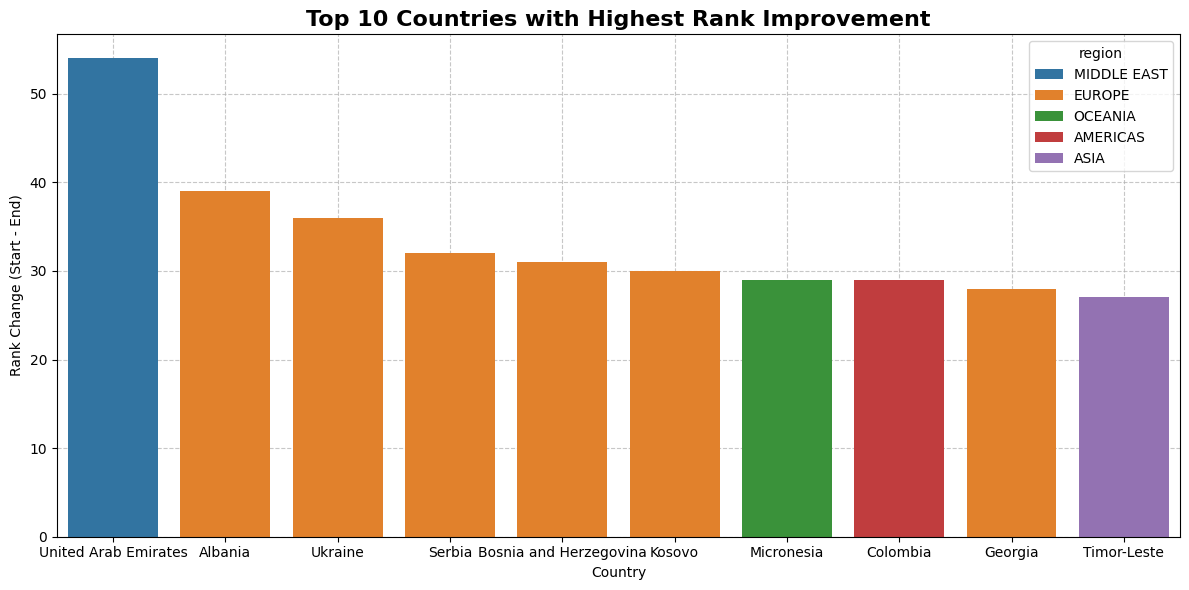

In [13]:
## Plot 1: Changes to to ranking, exploring across region and time using Barplot
top_10_gain = change_df.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_gain, x='country', y='rank_change', hue = 'region', zorder = 2)
plt.title('Top 10 Countries with Highest Rank Improvement', fontweight = 'bold', size = 16)
plt.ylabel('Rank Change (Start - End)')
plt.xlabel('Country')
plt.grid(axis='both', linestyle='--', alpha=0.7, zorder = 1)
plt.tight_layout()


#### **Comment:**

<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">
This bar chart highlights the top 10 countries that experienced the most significant improvements in their passport strength rankings between 2006 and 2025. The ranking improvement is measured by the difference between the starting and ending positions, where a higher value indicates a greater positive shift. The United Arab Emirates leads with a dramatic 54-rank increase, reflecting its substantial policy reforms and global mobility expansion. Notably, six out of the ten countries are from Europe, including Albania, Ukraine, and Serbia, indicating broader regional progress in visa liberalization. The chart also captures improvements from other parts of the world, including Micronesia (Oceania), Colombia (Americas), and Timor-Leste (Asia), suggesting that meaningful advances in passport access are not regionally isolated. The use of color-coded bars by region enhances comparative clarity and emphasizes the global nature of mobility shifts over the past two decades.
</div>

## <strong>Plot 2: Line Plot

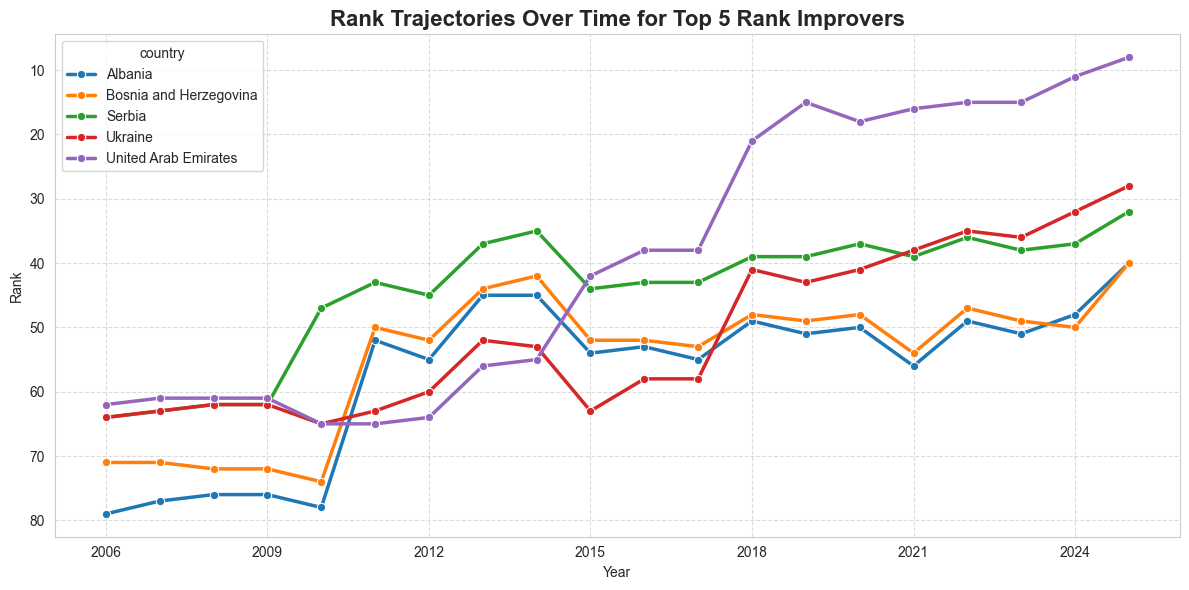

In [14]:
## Plot 2: Lineplot of top 5 improving countries over time
sns.set_style("whitegrid")
## Get top 5 countries with most improvement
top_5_countries = top_10_gain['country'].head(5).tolist()
## Get the data for top 5 countries
top5_data = rank_by_year[rank_by_year['country'].isin(top_5_countries)].copy()
## Reformat year as integer
top5_data['year'] = top5_data['year'].astype(int)

# Convert years to a sorted list of integers
years = sorted(top5_data['year'].unique())
## Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(data=top5_data, x='year', y='rank', hue='country', marker='o', linewidth = 2.5)
## invert y-axis to show rank 1 at the top
plt.gca().invert_yaxis()
plt.xticks(ticks = range(years[0],years[-1],3))  # Force integer ticksD
plt.title('Rank Trajectories Over Time for Top 5 Rank Improvers', fontweight = 'bold', size = 16)
plt.ylabel('Rank')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()



#### **Comment:**
<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">
This line chart tracks the annual ranking trajectories of the top five countries that achieved the greatest overall improvement in passport strength from 2006 to 2025. The inverted y-axis emphasizes upward movement as an improvement in rank, with rank 1 representing the strongest passport. The United Arab Emirates shows the most dramatic ascent, particularly from 2016 onward, ultimately reaching near the top of the global ranking. Ukraine and Serbia exhibit steady upward trends, while Albania and Bosnia and Herzegovina demonstrate moderate but consistent progress. The use of distinct colors and markers helps differentiate each country’s path, making the chart effective for visualizing long-term mobility growth and policy impact.

# <u><strong>Visualization 2</strong></u>

## <strong>Patterns in the changes in type of visa requirements

#### <strong>Data Preparation

In [15]:
# Helper function:
# Takes one cell from the visa columns (stored as JSON text) and returns
# how many destination countries are in that list.
def count_list(x):
    if pd.isna(x):
        return 0
    try:
        data = json.loads(x)
    except:
        return 0
    
    if isinstance(data, list):
        if len(data) > 0 and isinstance(data[0], list):
            data = data[0]
        return len(data)
    
    return 0

# Columns that indicate each type of visa requirement
visa_cols = [
    "visa_free_access",
    "visa_on_arrival",
    "electronic_travel_authorisation",
    "visa_online",
    "visa_required"
]

# Start with one row per passport
vc = country_list[["code", "country"]].copy()

# For each visa type, count how many destinations fall into that category
for col in visa_cols:
    vc[col + "_n"] = country_list[col].apply(count_list)

# Total number of destinations recorded across all visa types for each passport
vc["total"] = vc[[c + "_n" for c in visa_cols]].sum(axis=1)

# Keep only passports with at least one recorded destination
vc = vc[vc["total"] > 0].copy()

# Focus on "no pre-departure visa" access:
# visa-free + visa on arrival + electronic travel authorisation
vc["no_predep_n"] = (
    vc["visa_free_access_n"]
    + vc["visa_on_arrival_n"]
    + vc["electronic_travel_authorisation_n"]
)

# Share of destinations that are easy access (between 0 and 1)
vc["no_predep_share"] = vc["no_predep_n"] / vc["total"]

# Use the most recent year available in the ranking data
latest_year = rank_by_year["year"].max()

# Select the columns from the ranking data
cols = ["code", "country", "rank"]
if "region" in rank_by_year.columns:
    cols.append("region")

# Filter to the latest year only
latest_rank = rank_by_year[rank_by_year["year"] == latest_year][cols]

# Merge the rank info with our visa composition info
plot_df = (
    latest_rank
    .merge(vc[["code", "no_predep_share"]], on="code", how="left")
    .dropna(subset=["no_predep_share"])
)

plot_df.head()

,code,country,rank,region,no_predep_share
0,AF,Afghanistan,98,ASIA,0.110619
1,AL,Albania,40,EUROPE,0.544248
2,DZ,Algeria,79,AFRICA,0.243363
3,AO,Angola,85,AFRICA,0.212389
4,AG,Antigua and Barbuda,25,CARIBBEAN,0.672566


<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">

For this data preparation, the visa information in `country_list` is converted from JSON lists into simple counts for each visa type (visa-free, visa-on-arrival, eTA, visa-online, visa-required). For every passport, these counts are summed to get the total number of destinations and the number of “no pre-departure visa” destinations (visa-free + visa-on-arrival + eTA). Their ratio forms `no_predep_share`, the proportion of destinations that do not require a pre-departure visa. This summary is then merged with the latest year of the `rank_by_year` dataset so that each country’s current Henley rank (and region, if available) is linked to its `no_predep_share`, ready for visualization.

## <strong>Plot: Scatterplot<strong>

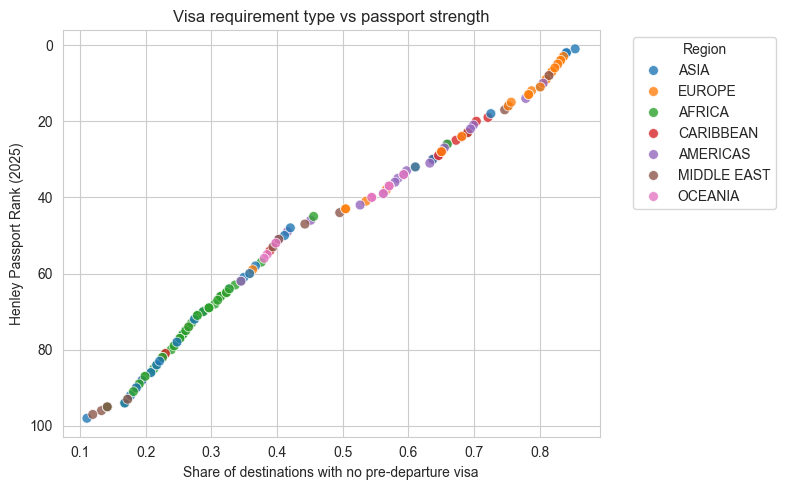

In [16]:
plt.figure(figsize=(8, 5))

hue_col = "region" if "region" in plot_df.columns else None

sns.scatterplot(
    data=plot_df,
    x="no_predep_share",
    y="rank",
    hue=hue_col,
    s=50,
    alpha=0.8
)

# Invert y-axis so rank 1 appears at the top
plt.gca().invert_yaxis()  # rank 1 at the top
plt.xlabel("Share of destinations with no pre-departure visa")
plt.ylabel(f"Henley Passport Rank ({latest_year})")
plt.title("Visa requirement type vs passport strength")

if hue_col:
    plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### **Comment:**

<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">
This scatterplot compares each country’s Henley Passport Rank in the most recent year with the share of its destinations that do not require a pre-departure visa (visa-free, visa-on-arrival, or electronic travel authorisation). Because the Henley Index is built around visa-free access, we see a clear upward trend: passports with a larger share of “no pre-departure visa” destinations tend to occupy stronger positions near the top of the inverted y-axis. More interestingly, the colour-coding by region reveals distinct clustering patterns, suggesting that some regions have a higher concentration of passports with extensive visa-free mobility, while others are more dispersed towards lower shares and weaker ranks. This highlights persistent regional disparities in travel freedom, even as overall passport strength is closely tied to the ease of entering other countries without prior visa arrangements.
</div>

# <u><strong>Visualization 3</strong></u>

## <strong>Trend of Global Passport Cohesion

#### <strong>Data Preparation

In [17]:
#extract year and visa free count, convert to numeric, drop na
year_and_vfc = rank_by_year.copy()
year_and_vfc["year"] = pd.to_numeric(year_and_vfc["year"], errors="coerce")
year_and_vfc["visa_free_count"] = pd.to_numeric(year_and_vfc["visa_free_count"], errors="coerce")
year_and_vfc = year_and_vfc.dropna(subset=["year", "visa_free_count"])

#Bin years into 5-year buckets
year_and_vfc["bucket"] = pd.cut(
    year_and_vfc["year"],
    bins=[2005, 2010, 2015, 2020, 2025],
    labels=["2006–2010", "2011-2015","2016–2020", "2021-2025"],
    include_lowest=True
)

#Average per country within bucket
vfcMean = (year_and_vfc.groupby(["country", "bucket"])["visa_free_count"]
         .mean()
         .reset_index(name="vfc_mean")
)

/var/folders/x3/w3qhyhl16ysb6c80lbnxgr600000gn/T/ipykernel_90469/3033993086.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vfcMean = (year_and_vfc.groupby(["country", "bucket"])["visa_free_count"]


<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">

For the data preparation, the year and visa_free_count fields are converted to numeric values in precaution, and removing records with missing entries in these key variables. Each valid observation is then assigned and binned to a five-year interval (2006–2010, 2011–2015, 2016–2020, 2021–2025), which allows the data to be examined in terms of broader phases rather than individual years. This not only make it more balanced for some years that has missing or removed values but also creates a more compact graph that is not too cluttered. Finally, the data is aggregated at the country level by computing the mean visa-free count (vfc_mean) for each country within each five-year period, providing a smoothed visual of how visa-free access has evolved over time across countries.

## <strong>Plot: Ridgeline-style, Stacked Graph

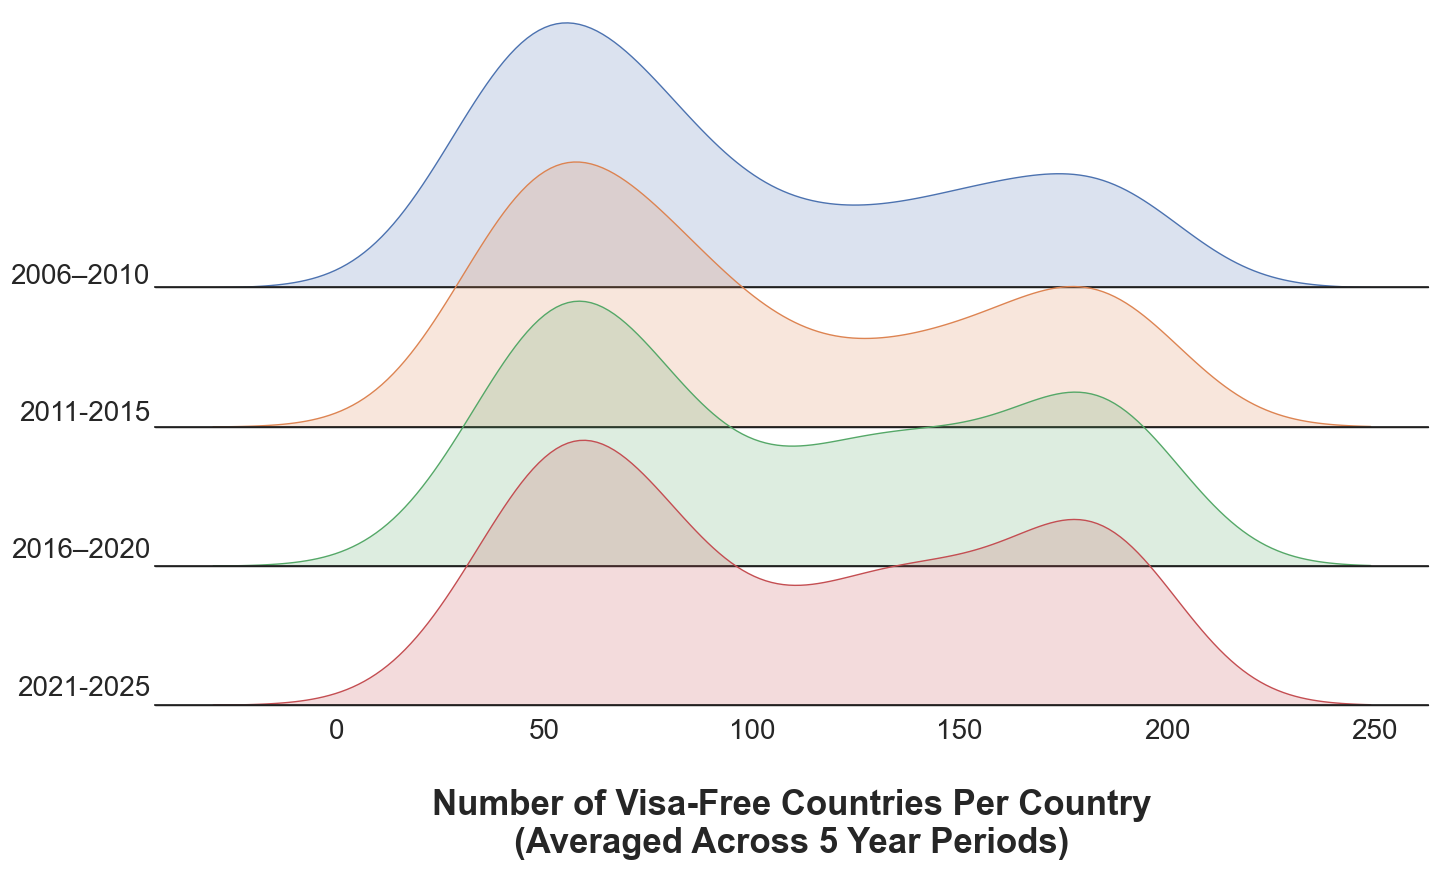

In [18]:
sns.set_theme(
    style="white",
    rc={"axes.facecolor": "none", "figure.facecolor": "none"}  # transparent backgrounds
)
rlg = sns.FacetGrid(vfcMean, row="bucket", hue="bucket", aspect=7, height=2, sharex=False, sharey=False)
rlg.map(sns.kdeplot, "vfc_mean", fill=True, alpha=0.2)
rlg.map(plt.axhline, y=0, lw=1, clip_on=False, color="black")

#Forcefully align the x labels
rlg.set_xlabels("\nNumber of Visa-Free Countries Per Country\n(Averaged Across 5 Year Periods)",size=25,fontweight='bold')
rlg.set_titles("")
rlg.set_ylabels("")

#for x-axis, remove x-ticks for the 4 top graphs except for bottom last row
for r in range(3):           
    xaxis = rlg.axes[r, 0]
    xaxis.tick_params(labelbottom=False)
    xaxis.set_xlabel("")   

bottom_ax = rlg.axes[-1, 0]
bottom_ax.tick_params(axis='x', labelsize=20)

#for each y-axis, remove y-ticks and add label to the left
for yaxis, label in zip(rlg.axes.flatten(), rlg.row_names):
    yaxis.set_yticks([])
    yaxis.spines['left'].set_visible(False)
    xmin, _ = yaxis.get_xlim()
    yaxis.text(xmin-1, 0.0005, str(label), ha="right", va="center",
            fontsize=20)  

rlg.figure.subplots_adjust(hspace=-0.5)  # tighten rows

plt.show()

#### **Comments**

<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">
From what we can observe from the above ridgeline-style graph, we can see that there is a slight rightward shift from the year 2006 to 2025, indicating an increase in the average number of visa-free destinations per country. 

From 2006-2010 to 2021-2025 we can see that the countries with more than 100 visa-free destinations increased while countries with less than 50 visa free destinations are decreasing. This shows that globally countries are increasing to be more cohesive and interconnected through visa-free travel. 

However, despite this shift, the distributional shape across the four 5-year periods is broadly similar, suggesting that changes in visa-free access occur gradually and slowly rather than abruptly.

## **References**
Henley & Partners. (n.d.). *The Henley Passport Index.* https://www.henleyglobal.com/passport-index/ranking 

## <u><strong>Task Contributions</strong></u>



<div style="border: 1px solid; padding: 12px 16px; border-radius: 8px; max-width: 800px; margin: 0 auto;">
  <ul style="line-height: 2;">
    <li>BUI XUAN PHONG (<u>A0309578M</u>) – Visualisation 2</li>
    <li>JEON MINHO (<u>A0272684U</u>) – Visualisation 3, HTML editing</li>
    <li>NGUYEN QUANG TRUNG (<u>A0305687U</u>) – Visualisation 1</li>
    <li>TANG CHAO YUAN (<u>A0307985M</u>) – Introduction, Summary Statistic</li>
    <li>YU ZHENGHAO (<u>A0311785B</u>) – Data cleaning</li>
  </ul>
</div>
